Task 2: Natural Language Processing (NLP) - Text Classification

Description: Classify text data into categories (e.g.,spam vs. non-spam, sentiment analysis).


Objectives

.Preprocess text data (tokenization, removing stopwords, stemming/lemmatization).

.Convert text into numerical representation using TF-IDF or Word2Vec.

.Train a classification model (e.g., Naive Bayes, Logistic Regression) on the processed text.

.Evaluate the model using precision, recall, and F1-score.

.Tools: Python, nltk, scikit-learn, pandas.

In [1]:
import pandas as pd
import os

print(os.listdir())

['Natural Language Processing (NLP).ipynb']


In [3]:
import pandas as pd
import zipfile
import urllib.request

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"

urllib.request.urlretrieve(url, "smsspamcollection.zip")

with zipfile.ZipFile("smsspamcollection.zip", "r") as zip_ref:
    zip_ref.extractall("sms_data")

df = pd.read_csv(
    "sms_data/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
#Inspecting the dataset
print(df.shape)
print(df["label"].value_counts())
print(df.isnull().sum())

(5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64
label      0
message    0
dtype: int64


In [ ]:
#Preprocess the text
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df["clean_message"] = df["message"].apply(clean_text)

df[["message", "clean_message"]].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


In [7]:
pip install nltk

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   -------------------------------

In [8]:
import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\JOSMAN\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [9]:
#Tokenize, remove stopwords, and stem

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def preprocess_text(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [stemmer.stem(word) for word in words]
    return " ".join(words)

df["processed_message"] = df["clean_message"].apply(preprocess_text)

df[["clean_message", "processed_message"]].head()

,clean_message,processed_message
0,go until jurong point crazy available only in ...,go jurong point crazi avail bugi n great world...
1,ok lar joking wif u oni,ok lar joke wif u oni
2,free entry in a wkly comp to win fa cup final...,free entri wkli comp win fa cup final tkt st m...
3,u dun say so early hor u c already then say,u dun say earli hor u c alreadi say
4,nah i dont think he goes to usf he lives aroun...,nah dont think goe usf live around though


In [10]:
#Convert text to numbers with TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df["processed_message"])
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5572, 7143)
y shape: (5572,)


# Split into training and testing data

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4457, 7143)
Testing data: (1115, 7143)


In [12]:
#Train the classification model

from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(y_pred[:10])

['ham' 'ham' 'ham' 'spam' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham']


In [13]:
#Evaluate the model
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.74      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



# Visualize the confusion matrix



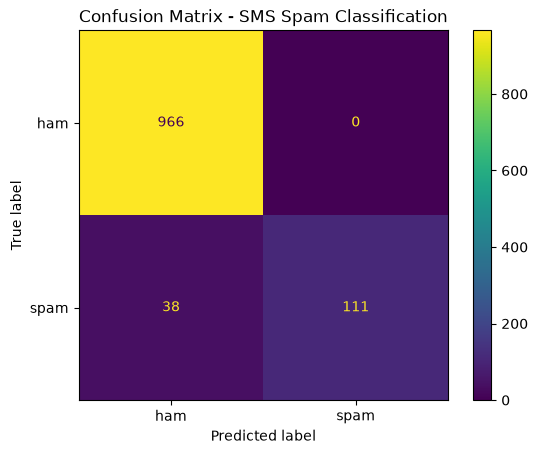

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix - SMS Spam Classification")
plt.show()



# Task 2 Report — NLP Text Classification

**Objective:**
Classify SMS messages as either **spam** or **ham (non-spam)** using Natural Language Processing and machine learning.

**Dataset:**

* 5,572 SMS messages
* 4,825 ham messages
* 747 spam messages
* No missing values

**Preprocessing:**

* Converted text to lowercase
* Removed punctuation and numbers
* Tokenized the text
* Removed English stopwords
* Applied Porter stemming

**Text Representation:**
Used **TF-IDF (Term Frequency–Inverse Document Frequency)** to convert the processed text into numerical features.

* Samples: **5,572**
* TF-IDF features: **7,143**

**Model:**
Used **Multinomial Naive Bayes** for classification.

**Train/Test Split:**

* Training: **4,457 messages (80%)**
* Testing: **1,115 messages (20%)**

**Evaluation:**

| Class | Precision | Recall | F1-score |
| ----- | --------: | -----: | -------: |
| Ham   |      0.96 |   1.00 |     0.98 |
| Spam  |      1.00 |   0.74 |     0.85 |

**Overall accuracy:** **0.97**

**Interpretation:**
The model achieved high overall performance. It correctly identified predicted spam messages with **100% precision**, meaning the messages it classified as spam were spam in the test set. However, its **74% recall for spam** shows that some actual spam messages were classified as ham.


